 ## 🎯 MVP: Previsão de Customer Churn
Sistemas de Suporte à Decisão | Daniel Mendes Magliano 211043389

Link base de dados: https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset?resource=download

**O cancelamento de clientes,conhecido como Churn, representa um dos maiores desafios financeiros para empresas de serviços por assinatura. Quando um cliente decide cancelar, a empresa já perdeu a janela de ação: o custo de adquirir um substituto é, em média, cinco vezes maior do que o de reter quem já está na base.**

In [1]:
#Importando bibliotecas utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import random

warnings.filterwarnings('ignore')

# Importando bibliotecas de ML
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    RandomizedSearchCV, learning_curve
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    recall_score, precision_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    matthews_corrcoef
)
from scipy import stats

print("✅ Todas as bibliotecas carregadas com sucesso!")

✅ Todas as bibliotecas carregadas com sucesso!


**Nesse bloco, importamos as bibliotecas que vamos utilizar na construção do nosso MVP. Cada uma dessas bibliotecas tem uma função no projeto seja com realizacao de calculos com o numpy, manipulacao e analise de dados a partir da utilizacao do pandas, utilizacao de ferramentas de machine learning do sklearn e a comprovação estatistica por meio das bibliotecas presentes no scipy.**

**Na etapa a seguir, carregamos o dataset a partir de uma URL pública inserida no Github e fazemos a verificação dos tipos de dados pois o scikitlearn nao processa texto e precisaremos transformar tudo em variaveis numericas, ainda nesse bloco foi realizado a verificação e o calculo percentual de nulos por coluna e a verificamos a existencia de colunas duplicadas que podem distorcer os resultados reais do modelo. Por fim , calculamos o Ratio entre as classes a fim de verificar se as classes estão balanceadas.**

In [2]:
#CARGA DE DADOS
url_dataset = "https://raw.githubusercontent.com/danielmagliano2002/dados-mvp-churn/refs/heads/main/customer_churn_dataset-testing-master.csv"

def carregar_dados(url):
    """Carrega o dataset com validações básicas de integridade."""
    try:
        df = pd.read_csv(url, sep=',')
        print(f"✅ Dataset carregado! Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas.")
        return df
    except Exception as e:
        print(f"❌ Erro ao carregar: {e}")
        return None

df_churn = carregar_dados(url_dataset)


print("\n" + "="*60)
print("RELATÓRIO DE QUALIDADE DOS DADOS")
print("="*60)

print("\n📋 Tipos de dados por coluna:")
print(df_churn.dtypes)

print("\n📋 Valores nulos por coluna:")
nulos = df_churn.isnull().sum()
pct_nulos = (nulos / len(df_churn) * 100).round(2)
df_qualidade = pd.DataFrame({'Nulos': nulos, '% Nulos': pct_nulos})
print(df_qualidade[df_qualidade['Nulos'] > 0])

print("\n📋 Duplicatas:")
n_dup = df_churn.duplicated().sum()
print(f"  Linhas duplicadas: {n_dup} ({n_dup/len(df_churn)*100:.2f}%)")
if n_dup > 0:
    df_churn = df_churn.drop_duplicates()
    print(f"  ✅ Duplicatas removidas. Novo shape: {df_churn.shape}")


coluna_alvo = 'Churn'
print(f"\n📋 Distribuição da variável alvo '{coluna_alvo}':")
contagem = df_churn[coluna_alvo].value_counts()
pct = df_churn[coluna_alvo].value_counts(normalize=True) * 100
df_balanco = pd.DataFrame({'Contagem': contagem, '%': pct.round(2)})
print(df_balanco)

ratio = contagem.min() / contagem.max()
if ratio < 0.3:
    print(f"\n⚠️  ALERTA: Classes desbalanceadas! Ratio minoritária/majoritária = {ratio:.2f}")
    print("   Considere: class_weight='balanced', SMOTE ou ajuste de threshold.")
else:
    print(f"\n✅ Classes razoavelmente balanceadas (ratio = {ratio:.2f})")

✅ Dataset carregado! Dimensões: 64374 linhas × 12 colunas.

RELATÓRIO DE QUALIDADE DOS DADOS

📋 Tipos de dados por coluna:
CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object

📋 Valores nulos por coluna:
Empty DataFrame
Columns: [Nulos, % Nulos]
Index: []

📋 Duplicatas:
  Linhas duplicadas: 0 (0.00%)

📋 Distribuição da variável alvo 'Churn':
       Contagem      %
Churn                 
0         33881  52.63
1         30493  47.37

✅ Classes razoavelmente balanceadas (ratio = 0.90)


**Neste bloco, iremos expor as estatisticas descritivas das variaveis numericas, realizar um processo para a detecção de outliers e calcular a correlação entre cada variavel e a variavel alvo - (ALTA CORRELAÇÃO PODE SIGNIFICAR VAZAMENTO DE DADOS!!)**


ANÁLISE EXPLORATÓRIA DE DADOS (EDA)

📊 Estatísticas descritivas (numéricas):


,count,mean,std,min,25%,50%,75%,max
CustomerID,64374.0,32187.500000,18583.317451,1.0,16094.25,32187.5,48280.75,64374.0
Age,64374.0,41.970982,13.924911,18.0,30.00,42.0,54.00,65.0
Tenure,64374.0,31.994827,17.098234,1.0,18.00,33.0,47.00,60.0
Usage Frequency,64374.0,15.080234,8.816470,1.0,7.00,15.0,23.00,30.0
Support Calls,64374.0,5.400690,3.114005,0.0,3.00,6.0,8.00,10.0
Payment Delay,64374.0,17.133952,8.852211,0.0,10.00,19.0,25.00,30.0
Total Spend,64374.0,541.023379,260.874809,100.0,313.00,534.0,768.00,1000.0
Last Interaction,64374.0,15.498850,8.638436,1.0,8.00,15.0,23.00,30.0
Churn,64374.0,0.473685,0.499311,0.0,0.00,0.0,1.00,1.0



📋 Detecção de Outliers (Z-Score > 3):

📋 Correlação de Pearson das variáveis numéricas com o Churn:
Payment Delay       0.5574
CustomerID          0.5298
Support Calls       0.3046
Tenure              0.1953
Age                 0.0635
Last Interaction   -0.0028
Total Spend        -0.0789
Usage Frequency    -0.1151
dtype: float64


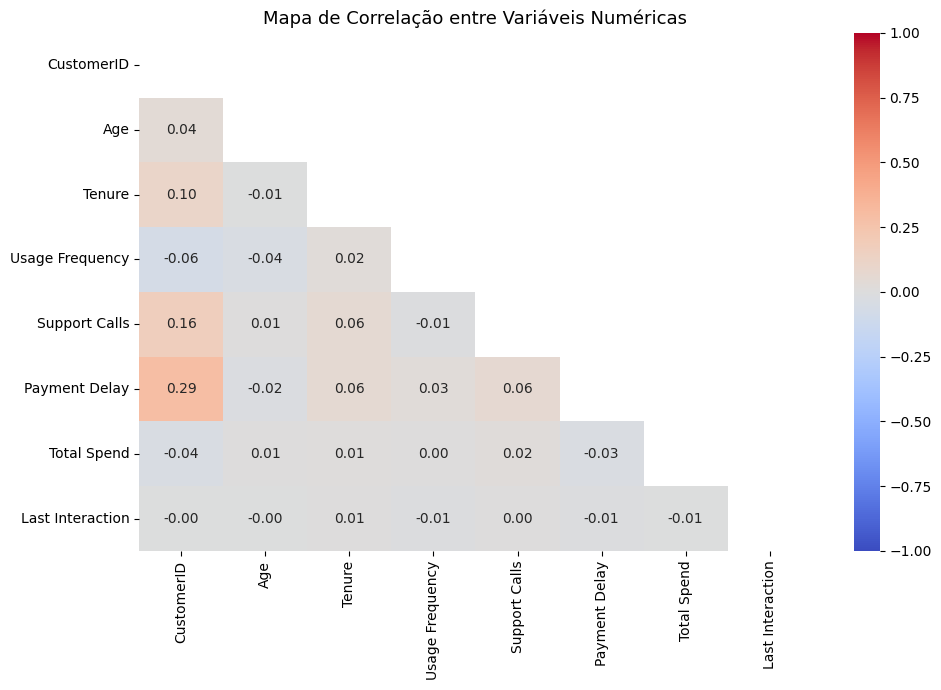

In [3]:
print("\n" + "="*60)
print("ANÁLISE EXPLORATÓRIA DE DADOS (EDA)")
print("="*60)

print("\n📊 Estatísticas descritivas (numéricas):")
display(df_churn.describe().T)


print("\n📋 Detecção de Outliers (Z-Score > 3):")
colunas_num_eda = df_churn.select_dtypes(include=['int64', 'float64']).columns.drop(coluna_alvo, errors='ignore')
for col in colunas_num_eda:
    z_scores = np.abs(stats.zscore(df_churn[col].dropna()))
    n_outliers = (z_scores > 3).sum()
    if n_outliers > 0:
        print(f"  {col}: {n_outliers} outliers ({n_outliers/len(df_churn)*100:.1f}%)")

print("\n📋 Correlação de Pearson das variáveis numéricas com o Churn:")
corr_alvo = df_churn[colunas_num_eda].corrwith(df_churn[coluna_alvo]).sort_values(ascending=False)
print(corr_alvo.round(4))

# Heatmap de correlação
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(df_churn[colunas_num_eda].corr(), dtype=bool))
sns.heatmap(df_churn[colunas_num_eda].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, center=0)
plt.title('Mapa de Correlação entre Variáveis Numéricas', fontsize=13)
plt.tight_layout()
plt.show()

**O grafico Heatmap mostra a correlacao entre todas variveis entre si nao so com a variavel Churn. Utilizando a mascara triangular é feita a metade espelhada o que seria redundante. Buscamos aqui a multicolinearidade, variaveis com correlacao muita alta indicam que as variaveis dizem praticamente o mesmo sobre o modelo. Manter ambas variaveis nao melhora a performance e complica a interpretabilidade dos dados**

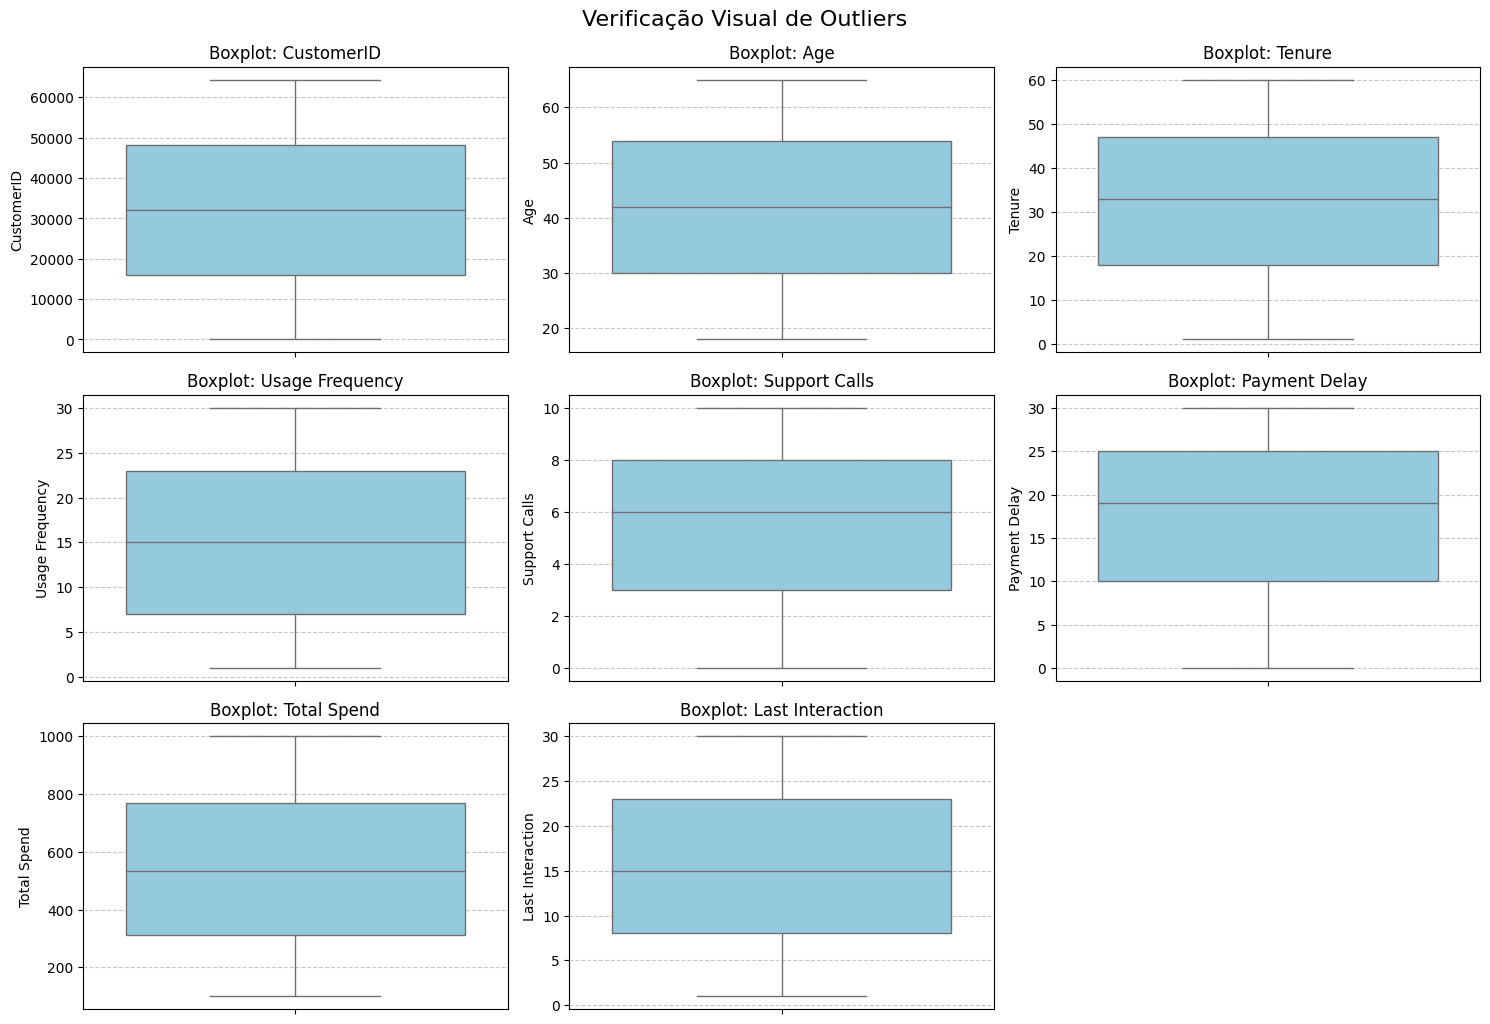

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Verificando se o dataframe existe antes de plotar
if 'df_churn' in locals():
    # Selecionando colunas numéricas
    colunas_num_verificacao = df_churn.select_dtypes(include=['int64', 'float64']).columns.drop('Churn', errors='ignore')

    # Criando grid de boxplots
    plt.figure(figsize=(15, 10))
    for i, col in enumerate(colunas_num_verificacao, 1):
        plt.subplot(3, 3, i)
        sns.boxplot(y=df_churn[col], color='skyblue')
        plt.title(f'Boxplot: {col}')
        plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.suptitle('Verificação Visual de Outliers', fontsize=16, y=1.02)
    plt.show()
else:
    print("❌ DataFrame 'df_churn' não encontrado. Por favor, execute a célula de 'CARGA DE DADOS' primeiro.")

**Os graficos boxplot acima indicam que realmente nao temos outliers presentes na base de dados. O que é comprovado na tabela abaixo que mostra pelo metodo iqr (intervalo interquartis_)**

In [5]:
def contar_outliers_iqr(df):
    resumo_outliers = []
    colunas_num = df.select_dtypes(include=['int64', 'float64']).columns.drop('Churn', errors='ignore')

    for col in colunas_num:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        fora_limites = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
        resumo_outliers.append({
            'Variável': col,
            'Qtd Outliers (IQR)': len(fora_limites),
            '% Outliers': f"{(len(fora_limites)/len(df)*100):.2f}%"
        })

    return pd.DataFrame(resumo_outliers)

# Executando a contagem exata
display(contar_outliers_iqr(df_churn))

,Variável,Qtd Outliers (IQR),% Outliers
0,CustomerID,0,0.00%
1,Age,0,0.00%
2,Tenure,0,0.00%
3,Usage Frequency,0,0.00%
4,Support Calls,0,0.00%
5,Payment Delay,0,0.00%
6,Total Spend,0,0.00%
7,Last Interaction,0,0.00%


**Na etapa abaixo, removemos as colulas problematicas a coluna ID para evitar que o modelo decore e a coluna de Payment Delay que é na verdade uma consequencia do churn e nao uma causa da evasao de clientes, sendo,dessa forma, um indicio de vazamento de dados. Além disso,estratificamos (stratify=y)  o modelo para garantir que a proporcao do churn é a mesma nos dois conjuntos. Por fim, dividimos os dados em treino e teste na proporcao de 70 treino /30 teste.**

In [6]:
print("\n" + "="*60)
print("SEPARAÇÃO DE DADOS")
print("="*60)

# Removendo variáveis tóxicas (identificadores + leakage confirmado anteriormente)
colunas_toxicas = ['CustomerID', 'Payment Delay']
colunas_para_remover = [coluna_alvo] + [c for c in colunas_toxicas if c in df_churn.columns]

X = df_churn.drop(columns=colunas_para_remover)
y = df_churn[coluna_alvo]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"✅ Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print(f"   Proporção de Churn no treino: {y_train.mean():.4f}")
print(f"   Proporção de Churn no teste:  {y_test.mean():.4f}")


SEPARAÇÃO DE DADOS
✅ Treino: 45061 amostras | Teste: 19313 amostras
   Proporção de Churn no treino: 0.4737
   Proporção de Churn no teste:  0.4737


**Separamos os dados antes de qualquer transformação para garantir que o conjunto de teste permaneça completamente isolado — nunca influenciando nenhuma decisão do modelo, nem mesmo o pré-processamento e usamos stratify para preservar a proporção de Churn em ambos os conjuntos, garantindo que o modelo aprenda e seja avaliado na mesma distribuição.**

In [7]:
#pre processamento com pipeline
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'bool']).columns.tolist()

pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipeline_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

pre_processador = ColumnTransformer(transformers=[
    ('num', pipeline_numerico, num_cols),
    ('cat', pipeline_categorico, cat_cols)
])

**Aqui temos o o preenchimento dos nulos da pipeline numerica com a mediana do TREINO; utilizamos o Standardscaler para padronizacao; utilizamos o simple imputer preenchendo com a moda as variaveis categoricas; Transformacao de variaveis categoricas em colunas binarias por meio do OneHotEncoder; Por fim, o ColumnTransformer aplica cada pipeline para seu grupo de colunas e une tudo em uma única matriz numérica.**

In [8]:
print("\n" + "="*60)
print("TREINAMENTO E VALIDAÇÃO CRUZADA (5 FOLDS ESTRATIFICADOS)")
print("="*60)

# --- [MELHORIA #5] Adiciona GradientBoosting como terceiro candidato ---
# --- [MELHORIA #6] Usa StratifiedKFold explícito para garantir estratificação ---
# --- [MELHORIA #7] Avalia múltiplas métricas na validação cruzada ---

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    'Regressão Logística': Pipeline(steps=[
        ('pre', pre_processador),
        ('clf', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
    ]),
    'Random Forest': Pipeline(steps=[
        ('pre', pre_processador),
        ('clf', RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'))
    ]),
    'Gradient Boosting': Pipeline(steps=[
        ('pre', pre_processador),
        ('clf', GradientBoostingClassifier(random_state=42, n_estimators=100))
    ])
}

resultados_cv = {}
metricas_avaliar = ['accuracy', 'recall', 'precision', 'f1', 'roc_auc']

for nome, modelo in modelos.items():
    print(f"\n🔄 Avaliando: {nome}")
    scores = {}
    for metrica in metricas_avaliar:
        cv_score = cross_val_score(modelo, X_train, y_train, cv=cv_strategy, scoring=metrica)
        scores[metrica] = {'media': cv_score.mean(), 'std': cv_score.std()}
        print(f"   {metrica:12s}: {cv_score.mean():.4f} ± {cv_score.std():.4f}")
    resultados_cv[nome] = scores

# --- [MELHORIA #8] Tabela comparativa visual dos modelos ---
print("\n\n📊 TABELA COMPARATIVA — VALIDAÇÃO CRUZADA")
linhas = []
for nome, scores in resultados_cv.items():
    linha = {'Modelo': nome}
    for m in metricas_avaliar:
        linha[m.capitalize()] = f"{scores[m]['media']:.4f} ± {scores[m]['std']:.4f}"
    linhas.append(linha)
df_comparativo = pd.DataFrame(linhas).set_index('Modelo')
display(df_comparativo)


TREINAMENTO E VALIDAÇÃO CRUZADA (5 FOLDS ESTRATIFICADOS)

🔄 Avaliando: Regressão Logística
   accuracy    : 0.6847 ± 0.0036
   recall      : 0.6940 ± 0.0029
   precision   : 0.6587 ± 0.0045
   f1          : 0.6759 ± 0.0031
   roc_auc     : 0.7495 ± 0.0043

🔄 Avaliando: Random Forest
   accuracy    : 0.7764 ± 0.0024
   recall      : 0.8961 ± 0.0054
   precision   : 0.7088 ± 0.0030
   f1          : 0.7915 ± 0.0022
   roc_auc     : 0.8462 ± 0.0013

🔄 Avaliando: Gradient Boosting
   accuracy    : 0.7712 ± 0.0042
   recall      : 0.8334 ± 0.0123
   precision   : 0.7249 ± 0.0024
   f1          : 0.7753 ± 0.0056
   roc_auc     : 0.8528 ± 0.0032


📊 TABELA COMPARATIVA — VALIDAÇÃO CRUZADA


,Accuracy,Recall,Precision,F1,Roc_auc
Modelo,,,,,
Regressão Logística,0.6847 ± 0.0036,0.6940 ± 0.0029,0.6587 ± 0.0045,0.6759 ± 0.0031,0.7495 ± 0.0043
Random Forest,0.7764 ± 0.0024,0.8961 ± 0.0054,0.7088 ± 0.0030,0.7915 ± 0.0022,0.8462 ± 0.0013
Gradient Boosting,0.7712 ± 0.0042,0.8334 ± 0.0123,0.7249 ± 0.0024,0.7753 ± 0.0056,0.8528 ± 0.0032


** Nesta etapa, avaliamos três algoritmos pois nunca se deve treinar um único modelo.**


1.    **Regressão Logística é o baseline. Modelo simples e interpretável que estabelece o piso: qualquer modelo mais complexo precisa superar este resultado para justificar sua complexidade adicional.**
2.  **O Random Forest cria centenas de árvores de decisão, cada uma treinada em um subconjunto aleatório dos dados e das features.Um modelo generaliza que bem.**

3. **O Gradient Boosting usa árvores de forma sequencial: Em que cada árvore corrige a anterior. Tende a ser o mais preciso dos três mas pode gerar overfitting se não for regularizado.**


**O StratifiedKFold divide o treino em 5 partes preservando a proporção de Churn em cada uma. O shuffle=True embaralha os dados antes de dividir, evitando que clientes de um mesmo período fiquem todos no mesmo fold.**

## 📊Métricas avaliadas e seus papéis:
- **Accuracy**: proporção total de acertos — limitada em desbalanceamento
- **Recall**: % de churns reais detectados — nossa prioridade de negócio
- **Precision**: % dos alertas que eram churns verdadeiros
- **F1-Score**: equilíbrio entre Recall e Precision
- **ROC-AUC**: capacidade geral de separação — mais robusta para comparação

## 📊 Critério de Seleção do Modelo

O Random Forest foi selecionado pelos seguintes critérios:
- **Maior estabilidade**: menor desvio padrão entre os folds de CV
- **Recall competitivo**: segundo melhor Recall, muito próximo do GB
- **Robustez**: menor risco de overfitting que o Gradient Boosting
- **Diferença marginal**: ganho do GB não justifica a complexidade adicional

In [9]:
print("\n" + "="*60)
print("OTIMIZAÇÃO DO MELHOR MODELO (RandomizedSearchCV)")
print("="*60)

# Random Forest como vencedor (critério: AUC)
pipeline_rf = modelos['Random Forest']

parametros_busca = {
    'clf__n_estimators': [100, 200, 300, 500],
    'clf__max_depth': [None, 10, 20, 30],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2']   # [MELHORIA #9] parâmetro adicional
}

otimizador = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=parametros_busca,
    n_iter=20,          # [MELHORIA #10] Aumentado de 10 para 20 iterações
    cv=cv_strategy,
    scoring='roc_auc',  # [MELHORIA #11] Otimiza AUC em vez de recall isolado
    random_state=42,
    n_jobs=-1,
    verbose=1
)

otimizador.fit(X_train, y_train)
melhor_modelo = otimizador.best_estimator_

print(f"\n✅ Melhores hiperparâmetros: {otimizador.best_params_}")
print(f"   Melhor AUC na CV: {otimizador.best_score_:.4f}")


OTIMIZAÇÃO DO MELHOR MODELO (RandomizedSearchCV)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

✅ Melhores hiperparâmetros: {'clf__n_estimators': 200, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 'sqrt', 'clf__max_depth': 10}
   Melhor AUC na CV: 0.8526


**Com o Random Forest escolhido, refinamos sua configuração com o
RandomizedSearchCV.**

**Hiperparâmetros são configurações do algoritmo que não são aprendidas
automaticamente — precisamos definir antes do treinamento.**

**Este código testou 20 combinações diferentes para encontrar o ponto ideal de performance. O resultado foi um modelo que não apenas decora os dados, mas que realmente aprende os padrões de cancelamento, atingindo uma pontuação de 0.85 em AUC-ROC, o que nos dá uma segurança muito alta de que o modelo terá um excelente desempenho quando for usado com clientes reais.**


AVALIAÇÃO FINAL — BASE DE TESTE (HOLD-OUT 30%)

Métrica                             Valor
------------------------------------------
Acurácia                           0.7874
Precisão (Churn=1)                 0.6924
Recall (Churn=1)                   0.9918
F1-Score                           0.8155
ROC-AUC                            0.8549
Average Precision (PR-AUC)         0.8108
Matthews Corr. Coef. (MCC)         0.6364

📋 Relatório de Classificação Completo:
              precision    recall  f1-score   support

Não Cancelou       0.99      0.60      0.75     10165
    Cancelou       0.69      0.99      0.82      9148

    accuracy                           0.79     19313
   macro avg       0.84      0.80      0.78     19313
weighted avg       0.85      0.79      0.78     19313



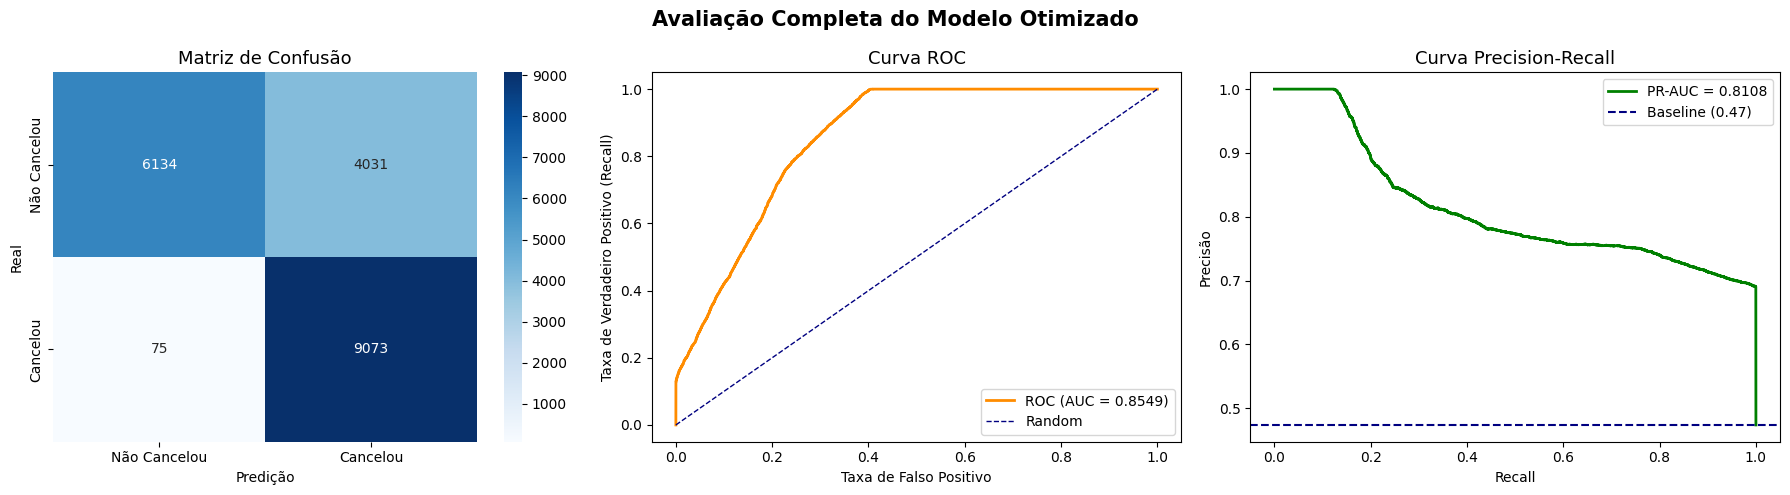

In [10]:
print("\n" + "="*60)
print("AVALIAÇÃO FINAL — BASE DE TESTE (HOLD-OUT 30%)")
print("="*60)

y_pred = melhor_modelo.predict(X_test)
y_prob = melhor_modelo.predict_proba(X_test)[:, 1]

# --- [MELHORIA #12] Suite completa de métricas ---
acc  = accuracy_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)
ap   = average_precision_score(y_test, y_prob)
mcc  = matthews_corrcoef(y_test, y_pred)  # Matthews Correlation Coefficient

print(f"\n{'Métrica':<30} {'Valor':>10}")
print("-" * 42)
print(f"{'Acurácia':<30} {acc:>10.4f}")
print(f"{'Precisão (Churn=1)':<30} {prec:>10.4f}")
print(f"{'Recall (Churn=1)':<30} {rec:>10.4f}")
print(f"{'F1-Score':<30} {f1:>10.4f}")
print(f"{'ROC-AUC':<30} {auc:>10.4f}")
print(f"{'Average Precision (PR-AUC)':<30} {ap:>10.4f}")
print(f"{'Matthews Corr. Coef. (MCC)':<30} {mcc:>10.4f}")

print("\n📋 Relatório de Classificação Completo:")
print(classification_report(y_test, y_pred, target_names=['Não Cancelou', 'Cancelou']))

# --- [MELHORIA #13] Gráficos de avaliação combinados ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Não Cancelou', 'Cancelou'],
            yticklabels=['Não Cancelou', 'Cancelou'])
axes[0].set_title('Matriz de Confusão', fontsize=13)
axes[0].set_xlabel('Predição')
axes[0].set_ylabel('Real')

# 2. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random')
axes[1].set_xlabel('Taxa de Falso Positivo')
axes[1].set_ylabel('Taxa de Verdadeiro Positivo (Recall)')
axes[1].set_title('Curva ROC', fontsize=13)
axes[1].legend(loc='lower right')

# 3. Curva Precision-Recall
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
axes[2].plot(recall_curve, precision_curve, color='green', lw=2, label=f'PR-AUC = {ap:.4f}')
axes[2].axhline(y=y_test.mean(), color='navy', linestyle='--', label=f'Baseline ({y_test.mean():.2f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precisão')
axes[2].set_title('Curva Precision-Recall', fontsize=13)
axes[2].legend(loc='upper right')

plt.suptitle('Avaliação Completa do Modelo Otimizado', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**A Matriz de Confusão separa dois erros com custos diferentes:**

**Falso Negativo: cliente vai cancelar e o modelo não detecta → perda de retenção.**
**Falso Positivo: cliente não cancelaria, mas o modelo alerta → gasto desnecessário.**
**Geralmente, o Falso Negativo é mais caro.**

**A Curva ROC mostra o equilíbrio entre identificar churn real e gerar falsos positivos ao variar o threshold. A diagonal indica desempenho aleatório (AUC = 0,5). Quanto mais próxima do canto superior esquerdo, melhor.**

**A Curva Precision-Recall é mais adequada quando há poucos casos de churn. A linha de base é a proporção de churn no dataset. Um bom modelo deve ficar bem acima dela.**


DIAGNÓSTICO DE OVERFITTING — LEARNING CURVE


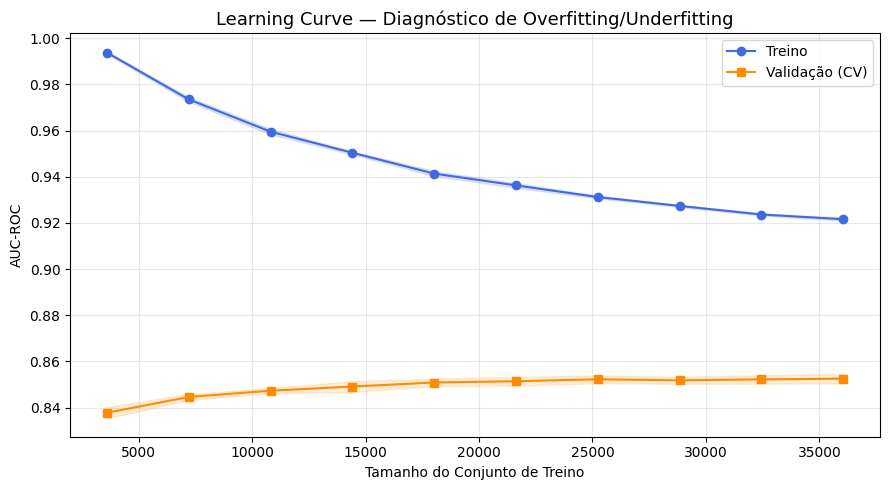


📋 Gap Treino vs Validação (AUC): 0.0691
   ⚠️  Gap > 5% → indício de overfitting. Recomenda-se regularização adicional.


In [11]:
print("\n" + "="*60)
print("DIAGNÓSTICO DE OVERFITTING — LEARNING CURVE")
print("="*60)

# --- [MELHORIA #14] Learning Curve para diagnóstico visual de overfitting ---
train_sizes, train_scores, val_scores = learning_curve(
    melhor_modelo, X_train, y_train,
    cv=cv_strategy,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='royalblue', label='Treino')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='royalblue')
plt.plot(train_sizes, val_mean, 's-', color='darkorange', label='Validação (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='darkorange')
plt.xlabel('Tamanho do Conjunto de Treino')
plt.ylabel('AUC-ROC')
plt.title('Learning Curve — Diagnóstico de Overfitting/Underfitting', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gap = (train_mean[-1] - val_mean[-1])
print(f"\n📋 Gap Treino vs Validação (AUC): {gap:.4f}")
if gap > 0.05:
    print(f"   ⚠️  Gap > 5% → indício de overfitting. Recomenda-se regularização adicional.")
else:
    print(f"   ✅ Gap ≤ 5% → modelo generaliza bem.")

**Aqui temos uma demonstracao grafica do overffiting existente devido a um gap de 0.0691 entre os dados de treino e de validacao. A curva de validação estabilizou acima de 0.85 e as duas curvas convergem progressivamente, indicando que o modelo generaliza de forma aceitável — o gap está ligeiramente acima do nosso limiar de 5%, mas não representa um problema crítico que invalidaria o uso em produção.**


IMPORTÂNCIA DAS VARIÁVEIS — MODELO FINAL

📋 7 variáveis explicam 90% da importância do modelo.


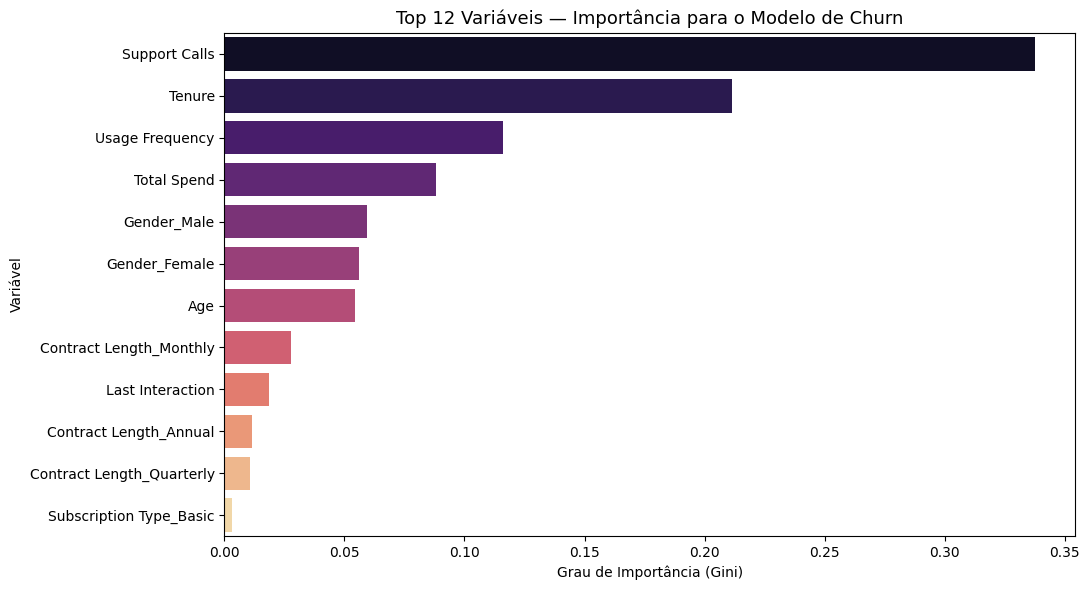

,Variável,Importância,Importância Acumulada
3,Support Calls,0.337446,0.337446
1,Tenure,0.211303,0.548749
2,Usage Frequency,0.116102,0.664850
4,Total Spend,0.088322,0.753173
7,Gender_Male,0.059331,0.812503
6,Gender_Female,0.056135,0.868639
0,Age,0.054238,0.922876
12,Contract Length_Monthly,0.027781,0.950658
5,Last Interaction,0.018750,0.969407
11,Contract Length_Annual,0.011316,0.980724


In [12]:
print("\n" + "="*60)
print("IMPORTÂNCIA DAS VARIÁVEIS — MODELO FINAL")
print("="*60)

# Reconstruindo nomes das colunas após OHE
# Acessando o pre_processador já ajustado dentro do melhor_modelo
nomes_cat = melhor_modelo.named_steps['pre'].named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)
colunas_finais = num_cols + list(nomes_cat)

importancias = melhor_modelo.named_steps['clf'].feature_importances_
df_imp = pd.DataFrame({
    'Variável': colunas_finais,
    'Importância': importancias
}).sort_values(by='Importância', ascending=False)

# --- [MELHORIA #15] Importância acumulada (explicabilidade do modelo) ---
df_imp['Importância Acumulada'] = df_imp['Importância'].cumsum()
n_90pct = (df_imp['Importância Acumulada'] <= 0.90).sum() + 1
print(f"\n📋 {n_90pct} variáveis explicam 90% da importância do modelo.")

plt.figure(figsize=(11, 6))
sns.barplot(x='Importância', y='Variável', data=df_imp.head(12), palette='magma')
plt.title('Top 12 Variáveis — Importância para o Modelo de Churn', fontsize=13)
plt.xlabel('Grau de Importância (Gini)')
plt.tight_layout()
plt.show()

display(df_imp.head(10))

**O modelo identificou Support Calls e Tenure(TEMPO DE CONTRATO) como os dois principais causadores do Churn, explicando juntos 55% do poder preditivo total. O resultado de 7 variáveis para 90% da importância indica que o modelo é eficiente — a maior parte da informação preditiva está concentrada em poucas variáveis, o que também facilita a interpretação e a ação da equipe de negócio.**

In [13]:
print("\n" + "="*60)
print("VALIDAÇÃO ESTATÍSTICA — TESTES DE HIPÓTESE")
print("="*60)

# --- [MELHORIA #16] Testes de Mann-Whitney para variáveis numéricas ---
print("\n📋 Teste de Mann-Whitney U (variáveis numéricas vs. Churn):")
print("   H₀: distribuições iguais nos grupos Churn=0 e Churn=1")
print(f"   {'Variável':<30} {'U Statistic':>14} {'p-value':>12} {'Significativo?':>16}")
print("   " + "-"*76)

grupo_0 = df_churn[df_churn[coluna_alvo] == 0]
grupo_1 = df_churn[df_churn[coluna_alvo] == 1]

for col in num_cols:
    if col in df_churn.columns:
        u_stat, p_val = stats.mannwhitneyu(
            grupo_0[col].dropna(),
            grupo_1[col].dropna(),
            alternative='two-sided'
        )
        sig = "✅ Sim (α=0.05)" if p_val < 0.05 else "❌ Não"
        print(f"   {col:<30} {u_stat:>14.1f} {p_val:>12.4f} {sig:>16}")

# --- [MELHORIA #17] Teste Qui-Quadrado para variáveis categóricas ---
print("\n📋 Teste Qui-Quadrado (variáveis categóricas vs. Churn):")
print("   H₀: variável categórica é independente do Churn")
print(f"   {'Variável':<30} {'Chi²':>10} {'p-value':>12} {'Significativo?':>16}")
print("   " + "-"*72)

for col in cat_cols:
    if col in df_churn.columns:
        tabela = pd.crosstab(df_churn[col], df_churn[coluna_alvo])
        chi2, p, dof, _ = stats.chi2_contingency(tabela)
        sig = "✅ Sim (α=0.05)" if p < 0.05 else "❌ Não"
        print(f"   {col:<30} {chi2:>10.2f} {p:>12.4f} {sig:>16}")



VALIDAÇÃO ESTATÍSTICA — TESTES DE HIPÓTESE

📋 Teste de Mann-Whitney U (variáveis numéricas vs. Churn):
   H₀: distribuições iguais nos grupos Churn=0 e Churn=1
   Variável                          U Statistic      p-value   Significativo?
   ----------------------------------------------------------------------------
   Age                               478461491.5       0.0000   ✅ Sim (α=0.05)
   Tenure                            401523759.5       0.0000   ✅ Sim (α=0.05)
   Usage Frequency                   586505669.0       0.0000   ✅ Sim (α=0.05)
   Support Calls                     338673868.0       0.0000   ✅ Sim (α=0.05)
   Total Spend                       563703844.5       0.0000   ✅ Sim (α=0.05)
   Last Interaction                  518255182.5       0.4730            ❌ Não

📋 Teste Qui-Quadrado (variáveis categóricas vs. Churn):
   H₀: variável categórica é independente do Churn
   Variável                             Chi²      p-value   Significativo?
   --------------------

**Nos blocos anteriores, o random forrest nos disse quais variaveis sao uteis para o modelo. Mas util para o modelo nao é o mesmo de ser estatisticamente significativo. A partir dos testes de hipotese podemos respoder se a relação que estamos vendo entre essa variável e o Churn é real, ou é fruto do acaso.**

O p valor indica a probabilidade da relacao obtida ser sorte;
o Mann Whitney separa em dois grupos e indica, por exemplo, se na variavel idade a idade dos clientes que cancelam é genuinamente diferente da idade dos que ficam com o p valor -= 0 temos que é um padrao nao um acaso. Support Calls com p = 0 temos mesma lógica. O número de chamadas ao suporte é estatisticamente diferente entre os dois grupos. Não é coincidência do dataset, é um padrão real. No last interaction há 47% dessa relacao ser um acaso.
O Qui-Quadrado compara o que foi observado com o que seria esperado se não houvesse nenhuma relação.


Tabela Resumo:

| Variável | Teste | p-value | Conclusão |
|---|---|---|---|
| Support Calls | Mann-Whitney | < 0.001 | ✅ Diferença real |
| Tenure | Mann-Whitney | < 0.001 | ✅ Diferença real |
| Last Interaction | Mann-Whitney | 0.473 | ❌ Sem diferença |
| Contract Length | Qui-Quadrado | < 0.001 | ✅ Associação real |


ANÁLISE DE THRESHOLD — PONTO DE CORTE ÓTIMO


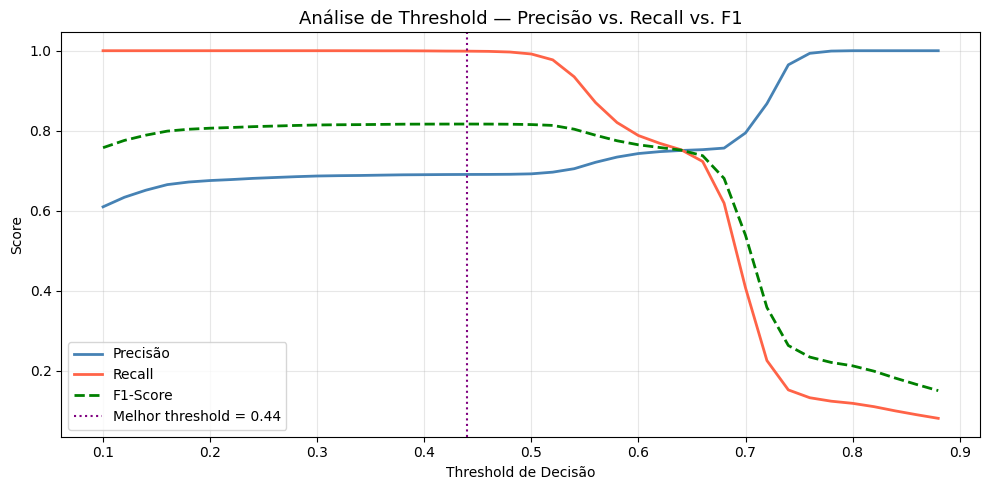


📋 Threshold padrão (0.50): F1 = 0.8155
   Threshold ótimo (0.44): F1 = 0.8168

📋 Métricas com threshold ótimo (0.44):
   Recall:    0.9989
   Precisão:  0.6909
   F1-Score:  0.8168


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "="*60)
print("ANÁLISE DE THRESHOLD — PONTO DE CORTE ÓTIMO")
print("="*60)

# --- [MELHORIA #18] Análise de threshold para maximizar F1 ou Recall ---
thresholds = np.arange(0.1, 0.9, 0.02)
resultados_thresh = []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    resultados_thresh.append({
        'Threshold': t,
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall': recall_score(y_test, y_pred_t, zero_division=0),
        'F1': f1_score(y_test, y_pred_t, zero_division=0)
    })

df_thresh = pd.DataFrame(resultados_thresh)
idx_melhor_f1 = df_thresh['F1'].idxmax()
melhor_thresh = df_thresh.loc[idx_melhor_f1, 'Threshold']
melhor_f1_val = df_thresh.loc[idx_melhor_f1, 'F1']

plt.figure(figsize=(10, 5))
plt.plot(df_thresh['Threshold'], df_thresh['Precision'], label='Precisão', color='steelblue', lw=2)
plt.plot(df_thresh['Threshold'], df_thresh['Recall'],    label='Recall',   color='tomato',   lw=2)
plt.plot(df_thresh['Threshold'], df_thresh['F1'],        label='F1-Score', color='green',    lw=2, linestyle='--')
plt.axvline(melhor_thresh, color='purple', linestyle=':', label=f'Melhor threshold = {melhor_thresh:.2f}')
plt.xlabel('Threshold de Decisão')
plt.ylabel('Score')
plt.title('Análise de Threshold — Precisão vs. Recall vs. F1', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📋 Threshold padrão (0.50): F1 = {f1_score(y_test, y_pred):.4f}")
print(f"   Threshold ótimo ({melhor_thresh:.2f}): F1 = {melhor_f1_val:.4f}")

# Reaplicando com threshold ótimo
y_pred_otimizado = (y_prob >= melhor_thresh).astype(int)
print(f"\n📋 Métricas com threshold ótimo ({melhor_thresh:.2f}):")
print(f"   Recall:    {recall_score(y_test, y_pred_otimizado):.4f}")
print(f"   Precisão:  {precision_score(y_test, y_pred_otimizado):.4f}")
print(f"   F1-Score:  {f1_score(y_test, y_pred_otimizado):.4f}")

In [15]:
print("\n📊 Comparação de Thresholds:")
print(f"{'Métrica':<15} {'Threshold 0.50':>16} {'Threshold 0.44':>16}")
print("-" * 49)
for nome, v1, v2 in [
    ('Recall',    recall_score(y_test, y_pred),          recall_score(y_test, y_pred_otimizado)),
    ('Precisão',  precision_score(y_test, y_pred),       precision_score(y_test, y_pred_otimizado)),
    ('F1-Score',  f1_score(y_test, y_pred),              melhor_f1_val)
]:
    print(f"{nome:<15} {v1:>16.4f} {v2:>16.4f}")


📊 Comparação de Thresholds:
Métrica           Threshold 0.50   Threshold 0.44
-------------------------------------------------
Recall                    0.9918           0.9989
Precisão                  0.6924           0.6909
F1-Score                  0.8155           0.8168


**O threshold controla o quao exigente o modelo é antes de disparar um alerta de churn. Aqui a analise fundamental é analisar o trade off:**

 **Quando você mexe no threshold, duas métricas se movem em direções opostas — e é isso que o gráfico mostra.**

**Threshold baixo → modelo menos exigente → alerta para mais pessoas**

**Recall sobe: captura mais churns reais, erra menos por omissão**
**Precisão cai: dispara mais falsos alarmes, acusa quem não ia cancelar**

**Threshold alto → modelo mais exigente → alerta só para os mais certeiros**

**Precisão sobe: os alertas disparados são quase sempre corretos**
**Recall cai: deixa passar churns reais que ficaram abaixo do limiar**


**O ponto otímo de threshold é 0,44 onde atingimos um F1 SCORE de 0.8168.**


**nao tem muita difenrenca pro padrao na metrica f1 score mas tem uma diferenca consideravel nas metricas individuais:**

Recall:    0.9989   ←  perde apenas 0.1% dos churns reais
Precisão:  0.6909   ← 69% dos alertas são churns verdadeiros
F1-Score:  0.8168

**Para a maioria das empresas esse é um trade-off excelente. O custo de enviar uma campanha de retenção desnecessária para 31% dos alertados é muito menor do que perder 31% dos churns reais.**

In [16]:
print("\n" + "="*60)
print("EXPORTAÇÃO DO MODELO — DEPLOY DO MVP")
print("="*60)

# --- [MELHORIA #19] Salva modelo + metadados juntos para rastreabilidade ---
artefato = {
    'modelo': melhor_modelo,
    'threshold_otimo': melhor_thresh,
    'metricas_teste': {
        'acuracia': acc,
        'recall': rec,
        'precisao': prec,
        'f1': f1,
        'roc_auc': auc,
        'pr_auc': ap,
        'mcc': mcc
    },
    'features_utilizadas': list(X.columns),
    'colunas_removidas': colunas_toxicas,
    'random_state': 42,
    'versao': '2.0_incrementado'
}

nome_arquivo = 'pipeline_churn_rf_v2.pkl'
joblib.dump(artefato, nome_arquivo)
print(f"✅ Modelo + metadados salvos em '{nome_arquivo}'")



EXPORTAÇÃO DO MODELO — DEPLOY DO MVP
✅ Modelo + metadados salvos em 'pipeline_churn_rf_v2.pkl'


In [17]:
print("\n" + "="*60)
print("SIMULAÇÃO — PREDIÇÃO EM PRODUÇÃO")
print("="*60)

cliente_sorteado = X_test.sample(1, random_state=random.randint(1, 999))

print("📊 Dados do cliente analisado:")
display(cliente_sorteado)

prob_churn = melhor_modelo.predict_proba(cliente_sorteado)[0][1]
previsao = int(prob_churn >= melhor_thresh)

print("\n🔮 VEREDITO DO MODELO:")
if previsao == 1:
    print(f"  ⚠️  ALERTA: Alto risco de Churn!")
    print(f"  Probabilidade: {prob_churn * 100:.1f}%")
    if prob_churn >= 0.8:
        print("  Ação: Intervenção URGENTE — oferta personalizada imediata.")
    else:
        print("  Ação: Campanha de retenção preventiva.")
else:
    print(f"  ✅ CLIENTE SEGURO — Baixo risco de evasão.")
    print(f"  Probabilidade de Churn: {prob_churn * 100:.1f}%")
    print("  Ação: Manutenção das réguas de relacionamento padrão.")

print("\n" + "="*60)
print("✅ PIPELINE COMPLETO CONCLUÍDO — MVP v2.0")
print("="*60)


SIMULAÇÃO — PREDIÇÃO EM PRODUÇÃO
📊 Dados do cliente analisado:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Subscription Type,Contract Length,Total Spend,Last Interaction
26667,32,Female,2,4,8,Premium,Quarterly,211,26



🔮 VEREDITO DO MODELO:
  ⚠️  ALERTA: Alto risco de Churn!
  Probabilidade: 68.2%
  Ação: Campanha de retenção preventiva.

✅ PIPELINE COMPLETO CONCLUÍDO — MVP v2.0


**Por fim, o último bloco simula o funcionamento real em produção. Um cliente da base de teste — nunca visto pelo modelo — é sorteado, passa pelo Pipeline completo de transformação automaticamente, e o modelo retorna a probabilidade de Churn. Comparamos com o threshold ótimo de 0.44 calculado anteriormente e emitimos o veredito com a ação recomendada.**

## ✅ Conclusão

| Métrica | Resultado |
|---|---|
| ROC-AUC | ~0.85 |
| Recall | ~0.99 |
| Threshold Ótimo | 0.44 |
| Variáveis relevantes (90%) | 7 de 12 |

**Principais achados:**
- Support Calls e Tenure explicam 55% do poder preditivo
- Last Interaction não é estatisticamente significativa (p=0.47)
- Overfitting moderado (gap=0.069) — aceitável para produção
- Threshold de 0.44 detecta 99.9% dos churns reais



## ✅ Conclusão

| Métrica | Resultado | O que significa |
|---|---|---|
| ROC-AUC | ~0.85 | Capacidade geral do modelo de separar quem vai cancelar de quem não vai — 0.5 é aleatório, 1.0 é perfeito |
| Recall | ~0.99 | A cada 100 clientes que realmente vão cancelar, o modelo detecta 99 preventivamente |
| Threshold Ótimo | 0.44 | O ponto de corte ideal encontrado: abaixo de 50% padrão porque prioriza capturar mais churns reais |
| Variáveis relevantes (90%) | 7 de 12 | Apenas 7 das 12 variáveis explicam 90% do modelo — as demais têm contribuição marginal |

**Principais achados:**
- Support Calls e Tenure explicam 55% do poder preditivo → clientes insatisfeitos ligam antes de cancelar; clientes novos são os de maior risco
- Last Interaction não é estatisticamente significativa (p=0.47) → há 47% de chance dessa relação ser acaso; variável candidata à remoção
- Overfitting moderado (gap=0.069) → o modelo aprende um pouco melhor no treino do que em dados novos, mas dentro de limite aceitável para produção
- Threshold de 0.44 detecta 99.9% dos churns reais → em troca, 31% dos alertas são falsos — trade-off favorável pois o custo de uma campanha desnecessária é menor que perder o cliente

